<a href="https://colab.research.google.com/github/AmitKunduA/Class_Assignment/blob/main/Ensemble_Learning_Six_Algo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ensemble Models: Bagging, Boosting & Stacking

**Dataset:** Kaggle business datasets (AI Job Market 2026 + Superstore Sales)

## 1. Setup & Installation

In [ ]:
# Install boosting libraries
!pip install xgboost lightgbm catboost -q

In [ ]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and model selection
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

# Ensemble models
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score,
)

#import warnings
#warnings.filterwarnings("ignore")

RANDOM_STATE = 20   # same seed everywhere -> reproducible results

## 2. Introduction to Ensemble Learning

An **ensemble** combines many models to get a better prediction than any single model.

| Type | Idea | Models |
|---|---|---|
| **Bagging** | Many models trained **in parallel** on random samples, then averaged | Random Forest, Extra Trees |
| **Boosting** | Models trained **one after another**, each fixing earlier errors | XGBoost, LightGBM, CatBoost |
| **Stacking** | A **meta-model** learns how to combine different models | Stacking Classifier |

## 3. Dataset: AI Job Market 2026

**Source:** Kaggle

**Link:** https://www.kaggle.com/datasets/mariaaqdas/ai-job-market-2026-automation-vs-traditional-role

**Description:** Job postings from the US, UK and India (2026)

**Features used:**
- Job category
- Contract type (permanent / contract)
- Contract time (full time / part time)
- Country
- Average salary
- Salary is predicted (0/1)

**Target:** `is_ai_related` → 0 = Traditional role, 1 = AI-related role

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/python/ai_job_market_dataset.csv')
df.head()

Mounted at /content/drive


,search_keyword,search_country,id,title,company,location,category,contract_type,contract_time,salary_min,salary_max,salary_is_predicted,created,description,is_ai_related,salary_avg,created_date,currency,country_name
0,artificial intelligence,gb,5822242641,Senior Technologist Artificial Intelligence R ...,Hackajob Ltd,"Great Baddow, Chelmsford",Engineering Jobs,permanent,NaN,40000.00,40000.00,0,2026-07-31 11:09:48+00:00,hackajob is partnering directly with BAE Syste...,True,40000.00,2026-07-31,GBP,United Kingdom
1,artificial intelligence,gb,5727313687,Artificial Intelligence,Adria Solutions,"Altrincham, Greater Manchester",IT Jobs,NaN,NaN,53702.83,53702.83,1,2026-05-12 22:05:22+00:00,AI Engineer - Manchester - Circa £50K Our clie...,True,53702.83,2026-05-12,GBP,United Kingdom
2,artificial intelligence,gb,5736675451,Artificial Intelligence Engineer,Oxford Dynamics,UK,IT Jobs,permanent,full_time,74422.25,74422.25,1,2026-05-21 21:07:04+00:00,Artificial Intelligence Engineers Contract: Pe...,True,74422.25,2026-05-21,GBP,United Kingdom
3,artificial intelligence,gb,5824444000,Artificial Intelligence Engineer,Quantiphi,"London, UK",IT Jobs,NaN,full_time,53031.54,53031.54,1,2026-08-01 18:29:25+00:00,"While technology is the heart of our business,...",True,53031.54,2026-08-01,GBP,United Kingdom
4,artificial intelligence,gb,5844156514,Artificial Intelligence Engineer,Discover International,"Monument, Central London",IT Jobs,contract,full_time,52000.00,60000.00,0,2026-08-16 11:39:19+00:00,"Salary: £52,000 - 60,000 per year Requirements...",True,56000.00,2026-08-16,GBP,United Kingdom


## 4. Data Exploration

In [ ]:
# Column types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1696 entries, 0 to 1695
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   search_keyword       1696 non-null   object 
 1   search_country       1696 non-null   object 
 2   id                   1696 non-null   int64  
 3   title                1696 non-null   object 
 4   company              1695 non-null   object 
 5   location             1696 non-null   object 
 6   category             1696 non-null   object 
 7   contract_type        432 non-null    object 
 8   contract_time        826 non-null    object 
 9   salary_min           1513 non-null   float64
 10  salary_max           1513 non-null   float64
 11  salary_is_predicted  1696 non-null   int64  
 12  created              1696 non-null   object 
 13  description          1696 non-null   object 
 14  is_ai_related        1696 non-null   bool   
 15  salary_avg           1513 non-null   f

In [ ]:
# Summary statistics of numeric columns
df.describe().round(2)

,id,salary_min,salary_max,salary_is_predicted,salary_avg
count,1.696000e+03,1513.00,1513.00,1696.00,1513.00
mean,5.771004e+09,77299.04,87277.96,0.68,82288.50
std,3.734309e+08,97136.33,183696.58,0.46,137576.35
min,1.155089e+09,0.00,13.00,0.00,13.00
25%,5.805809e+09,34886.79,35043.05,0.00,35000.00
50%,5.830417e+09,54600.00,55145.76,1.00,55000.00
75%,5.841228e+09,97600.78,100000.00,1.00,98968.77
max,5.846513e+09,2000000.00,5000000.00,1.00,3500000.00


## 5. Data Cleaning

- Keep only the columns we use as features
- Fill missing values
- Convert the target to 0/1

In [ ]:
TARGET = "is_ai_related"
class_names = ["Traditional", "AI-related"]

features = ["category", "contract_type", "contract_time", "country_name",
            "salary_avg", "salary_is_predicted"]
df = df[features + [TARGET]].copy()

# Fill missing values
df["contract_type"] = df["contract_type"].fillna("unknown")
df["contract_time"] = df["contract_time"].fillna("unknown")
df["salary_avg"]    = df["salary_avg"].fillna(df["salary_avg"].median())

df[TARGET] = df[TARGET].astype(int)
df = df.drop_duplicates()
df.head()

,category,contract_type,contract_time,country_name,salary_avg,salary_is_predicted,is_ai_related
0,Engineering Jobs,permanent,unknown,United Kingdom,40000.00,0,1
1,IT Jobs,unknown,unknown,United Kingdom,53702.83,1,1
2,IT Jobs,permanent,full_time,United Kingdom,74422.25,1,1
3,IT Jobs,unknown,full_time,United Kingdom,53031.54,1,1
4,IT Jobs,contract,full_time,United Kingdom,56000.00,0,1


## 6. Preprocessing & Train/Test Split

In [ ]:
# Features (X) and target (y)
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Convert text columns to numbers
for col in X.select_dtypes(exclude="number").columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

X.head()

,category,contract_type,contract_time,country_name,salary_avg,salary_is_predicted
0,5,1,2,1,40000.00,0
1,10,2,2,1,53702.83,1
2,10,1,0,1,74422.25,1
3,10,2,0,1,53031.54,1
4,10,0,0,1,56000.00,0


In [ ]:
# Stratified 80/20 split keeps class proportions equal in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples : {len(X_test)}")

Training samples: 1158
Testing samples : 290


## 7. Model 1: Random Forest

- Many decision trees trained on random samples of the data (**bagging**)
- Final prediction = majority vote of all trees

In [ ]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)#n_jobs=-1,hyper parameter tuining
rf_model.fit(X_train, y_train)

rf_pred  = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)   # probabilities -> needed for ROC/AUC,confusion matrix

print(f"Random Forest | accuracy = {accuracy_score(y_test, rf_pred):.4f}")

Random Forest | accuracy = 0.9241


## 8. Model 2: Extra Trees

- Like Random Forest, but split points are chosen **randomly**
- Faster, and often less overfitting

In [ ]:
# Extra Trees
et_model = ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
et_model.fit(X_train, y_train)

et_pred  = et_model.predict(X_test)
et_proba = et_model.predict_proba(X_test)

print(f"Extra Trees | accuracy = {accuracy_score(y_test, et_pred):.4f}")

Extra Trees | accuracy = 0.9207


## 9. Model 3: XGBoost

- Trees are built **one after another**; each new tree fixes the errors of the previous ones (**boosting**)
- Great balance of speed and accuracy

In [ ]:
# XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                              random_state=RANDOM_STATE)
xgb_model.fit(X_train, y_train)

xgb_pred  = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)

print(f"XGBoost | accuracy = {accuracy_score(y_test, xgb_pred):.4f}")

XGBoost | accuracy = 0.9448


## 10. Model 4: LightGBM

- Boosting with fast, histogram-based trees
- Best for large datasets

In [ ]:
# LightGBM
lgb_model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                               random_state=RANDOM_STATE)
lgb_model.fit(X_train, y_train)

lgb_pred  = lgb_model.predict(X_test)
lgb_proba = lgb_model.predict_proba(X_test)

print(f"LightGBM | accuracy = {accuracy_score(y_test, lgb_pred):.4f}")

LightGBM | accuracy = 0.9414


## 11. Model 5: CatBoost

- Boosting designed for categorical features
- Robust with little tuning

In [ ]:
# CatBoost
cat_model = CatBoostClassifier(iterations=200, learning_rate=0.1, depth=5,
                               random_state=RANDOM_STATE, verbose=0) #all output shows verbose
cat_model.fit(X_train, y_train)

cat_pred  = cat_model.predict(X_test).ravel().astype(int)   # flatten to 1-D labels
cat_proba = cat_model.predict_proba(X_test)

print(f"CatBoost | accuracy = {accuracy_score(y_test, cat_pred):.4f}")

CatBoost | accuracy = 0.9483


## 12. Model 6: Stacking Ensemble

- The 5 models above are the **base models**
- A **meta-model** (Logistic Regression) learns how to combine their predictions

In [ ]:
# Stacking: 5 base models + Logistic Regression as the meta-model
stack_model = StackingClassifier(
    estimators=[("rf", rf_model), ("et", et_model), ("xgb", xgb_model),
                ("lgb", lgb_model), ("cat", cat_model)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
)
stack_model.fit(X_train, y_train)

stack_pred  = stack_model.predict(X_test)
stack_proba = stack_model.predict_proba(X_test)

print(f"Stacking | accuracy = {accuracy_score(y_test, stack_pred):.4f}")

Stacking | accuracy = 0.9517


## 13. Model Comparison

All models compared on the test set: accuracy, precision, recall, F1 score (macro and weighted average) and ROC-AUC.

In [ ]:
models = {
    "Random Forest": (rf_pred, rf_proba),
    "Extra Trees":   (et_pred, et_proba),
    "XGBoost":       (xgb_pred, xgb_proba),
    "LightGBM":      (lgb_pred, lgb_proba),
    "CatBoost":      (cat_pred, cat_proba),
    "Stacking":      (stack_pred, stack_proba),
}

rows = []
for name, (pred, proba) in models.items():
    rows.append({
        "Model":                name,
        "Accuracy":             accuracy_score(y_test, pred),
        "Precision (macro)":    precision_score(y_test, pred, average="macro"),
        "Recall (macro)":       recall_score(y_test, pred, average="macro"),
        "F1 (macro)":           f1_score(y_test, pred, average="macro"),
        "Precision (weighted)": precision_score(y_test, pred, average="weighted"),
        "Recall (weighted)":    recall_score(y_test, pred, average="weighted"),
        "F1 (weighted)":        f1_score(y_test, pred, average="weighted"),
        "ROC-AUC":              roc_auc_score(y_test, proba[:, 1]),
    })

results = pd.DataFrame(rows).sort_values("F1 (macro)", ascending=False).reset_index(drop=True)
best_model = results.iloc[0]["Model"]
results.round(4)

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),Precision (weighted),Recall (weighted),F1 (weighted),ROC-AUC
0,Stacking,0.9517,0.9527,0.9486,0.9505,0.9519,0.9517,0.9516,0.9822
1,CatBoost,0.9483,0.9486,0.9456,0.9470,0.9483,0.9483,0.9482,0.9796
2,XGBoost,0.9448,0.9456,0.9416,0.9434,0.9449,0.9448,0.9447,0.9814
3,LightGBM,0.9414,0.9405,0.9396,0.9401,0.9413,0.9414,0.9413,0.9776
4,Random Forest,0.9241,0.9214,0.9246,0.9228,0.9248,0.9241,0.9243,0.9809
5,Extra Trees,0.9207,0.9181,0.9205,0.9192,0.9211,0.9207,0.9208,0.9588


## Macro vs. Weighted Average

| Average | How it is computed | Meaning |
|---|---|---|
| **Macro** | Simple mean of the per-class scores | Every class counts **equally** |
| **Weighted** | Mean weighted by the number of samples in each class | Bigger classes count **more** |



## 14. Confusion Matrix

Rows = **actual** class, columns = **predicted** class. The diagonal shows correct predictions.

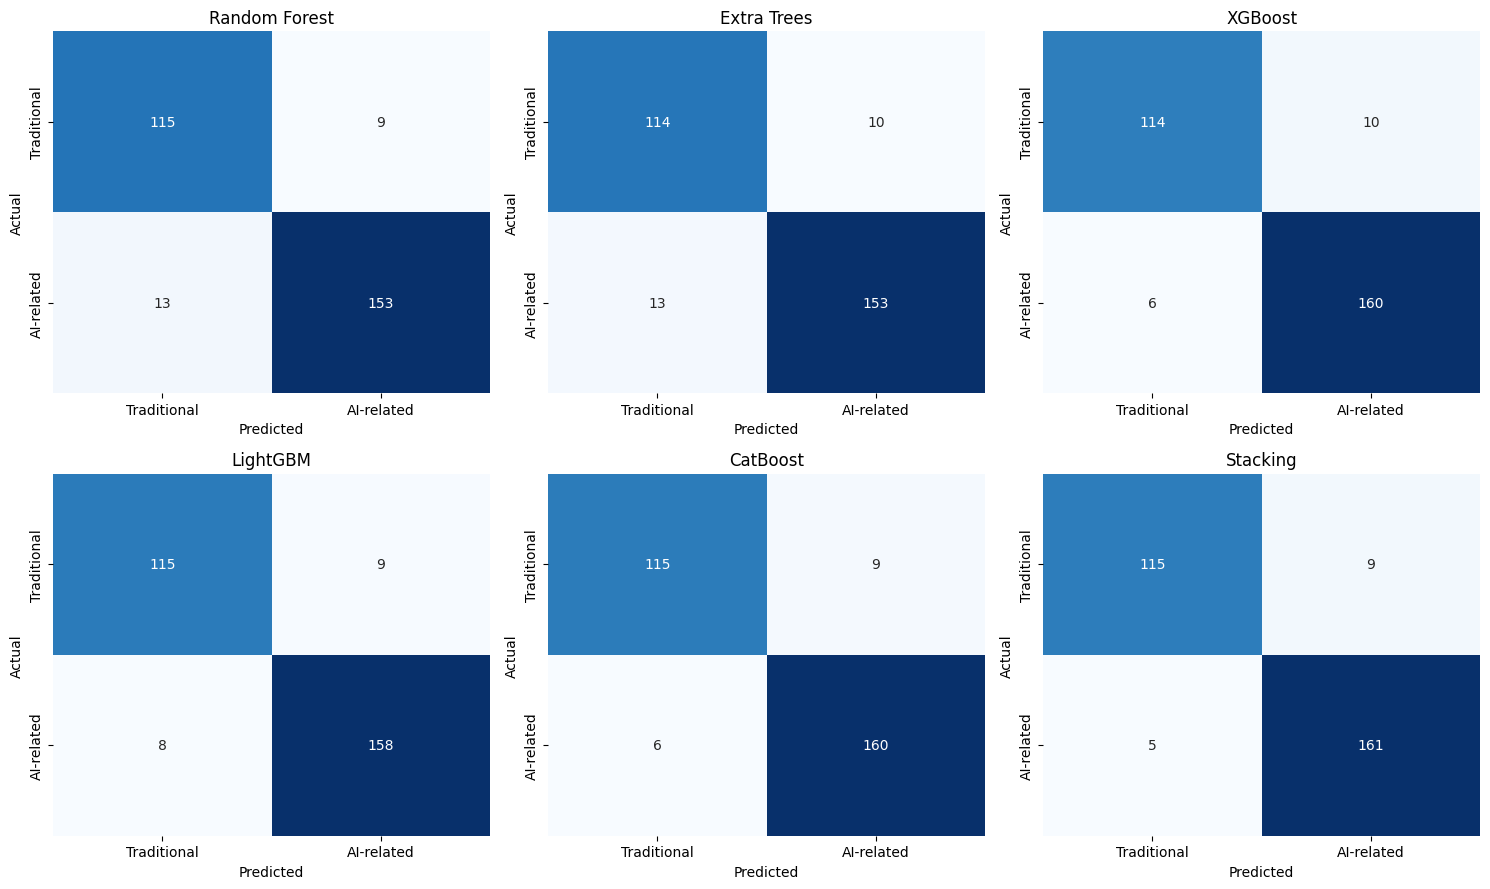

In [ ]:
# Confusion matrix for every model
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (name, (pred, proba)) in zip(axes.ravel(), models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


## 16. ROC Curve & AUC Score

The ROC curve shows how well each model separates the classes.
A higher AUC (closer to 1.0) means better performance.

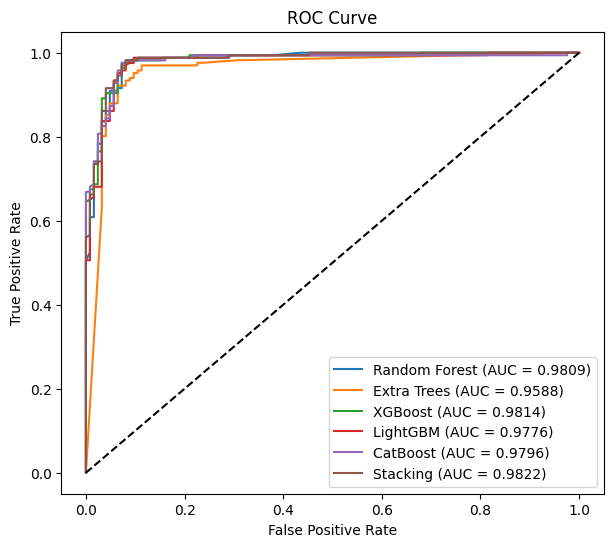

In [ ]:
# ROC curve + AUC for all six models
plt.figure(figsize=(7, 6))
for name, (pred, proba) in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba[:, 1])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.4f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 17. Key Takeaways

1. **Bagging** (Random Forest, Extra Trees): strong and simple baselines
2. **Boosting** (XGBoost, LightGBM, CatBoost): usually the best single models on tabular data
3. **Stacking**: combines different models; often a small extra gain, but slower

**Evaluation:**
- **Accuracy** alone is not enough – also check precision, recall and F1
- **Macro average** treats all classes equally; **weighted average** follows class size
- **Confusion matrix** shows *which* classes are confused
- **ROC-AUC** measures how well the model separates the classes (1.0 = perfect)

**Important parameters:**
- **n_estimators / iterations:** number of trees
- **learning_rate:** step size of boosting
- **max_depth / depth:** tree complexity

---



## 1 Superstore Profitability Prediction

**Dataset:** Superstore Sales

**Kaggle Link:** https://www.kaggle.com/datasets/himanshuuike/superstore-sales-dataset


**Target:** create `profit_class` from the profit margin (= Profit / Sales):

| Class | Rule |
|---|---|
| 0 – Loss | Profit < 0 |
| 1 – Low margin | margin < 0.25 |
| 2 – High margin | margin ≥ 0.25 |

---



##1.1 Load and Explore Data

In [1]:
!pip install xgboost lightgbm catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.3 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,label_binarize,StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier,StackingClassifier,ExtraTreesClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier #******

from sklearn.metrics import (
    accuracy_score,precision_score,recall_score,f1_score,
    classification_report,confusion_matrix,roc_curve,
    auc,roc_auc_score
)

RANDOM_STATE = 20

In [3]:
from google.colab import drive
drive.mount('/content/drive')

df=pd.read_csv('/content/drive/MyDrive/python/samplesuperstore.csv')
df.head()

Mounted at /content/drive


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [4]:
df.shape

(10194, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [6]:
df.describe().round(2)

,Row ID,Sales,Quantity,Discount,Profit
count,10194.00,10194.00,10194.00,10194.00,10194.00
mean,5097.50,228.23,3.79,0.16,28.67
std,2942.90,619.91,2.23,0.21,232.47
min,1.00,0.44,1.00,0.00,-6599.98
25%,2549.25,17.22,2.00,0.00,1.76
50%,5097.50,53.91,3.00,0.20,8.69
75%,7645.75,209.50,5.00,0.20,29.30
max,10194.00,22638.48,14.00,0.80,8399.98


## 1.2 Data Cleaning,Preprocessing and Train_Test_Split

In [7]:
TARGET = "profit_class"
class_names = ["Loss", "Low margin", "High margin"]

margin = df["Profit"] / df["Sales"]
df[TARGET] = np.select([df["Profit"] < 0, margin < 0.25], [0, 1], default=2)

features = ["Ship Mode", "Segment", "Region", "Category", "Sub-Category",
            "Sales", "Quantity", "Discount"]
df = df[features + [TARGET]].drop_duplicates()
df.head()

,Ship Mode,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount,profit_class
0,Standard Class,Consumer,Central,Office Supplies,Paper,16.448,2,0.2,2
1,Standard Class,Home Office,Central,Office Supplies,Binders,3.540,2,0.8,0
2,Standard Class,Home Office,Central,Office Supplies,Labels,11.784,3,0.2,2
3,Standard Class,Home Office,Central,Office Supplies,Storage,272.736,3,0.2,0
4,Standard Class,Consumer,East,Office Supplies,Art,19.536,3,0.2,2


In [8]:
df.shape

(9757, 9)

In [16]:
X=df.drop(columns=[TARGET])
y=df[TARGET]

for col in X.select_dtypes(exclude='number').columns:
    X[col]=LabelEncoder().fit_transform(X[col].astype(str))


X.head()


,Ship Mode,Segment,Region,Category,Sub-Category,Sales,Quantity,Discount
0,3,0,0,1,12,16.448,2,0.2
1,3,2,0,1,3,3.540,2,0.8
2,3,2,0,1,10,11.784,3,0.2
3,3,2,0,1,14,272.736,3,0.2
4,3,0,1,1,2,19.536,3,0.2


In [15]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=RANDOM_STATE,stratify=y
)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

print(f'Train Size:{len(X_train)}')
print(f'Test Size:{len(X_test)}')

Train Size:7805
Test Size:1952


## 1.3 Random Forest

In [24]:
rf_model=RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train,y_train)

rf_pred  = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)

print(f'Random Forest|Accuracy:{accuracy_score(y_test,rf_pred):.4f}')

Random Forest|Accuracy:0.8222


## 1.4 Extra Trees

In [28]:
et_model = ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
et_model.fit(X_train,y_train)

et_pred = et_model.predict(X_test)
et_proba= et_model.predict_proba(X_test)

print(f'Extra Trees|Accuracy:{accuracy_score(y_test,et_pred):.4f}')

Extra Trees|Accuracy:0.8145


## 1.5 XGBoost

In [39]:
xgb_model=xgb.XGBClassifier(n_estimators=200, random_state=RANDOM_STATE, learning_rate=0.01,
                            max_depth=8)
xgb_model.fit(X_train,y_train)

xgb_pred =xgb_model.predict(X_test)
xgb_proba=xgb_model.predict_proba(X_test)

print(f'XGBoost|Accuracy:{accuracy_score(y_test, xgb_pred):.4f}')

XGBoost|Accuracy:0.7649


## 1.6 LightGBM

In [52]:
lgb_model=lgb.LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, learning_rate=0.01,
                             max_depth=5, verbose=-1)
lgb_model.fit(X_train, y_train)

lgb_pred =lgb_model.predict(X_test)
lgb_proba=lgb_model.predict_proba(X_test)

print(f'LightGBM|Accuracy:{accuracy_score(y_test, lgb_pred):.4f}')

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM|Accuracy:0.8509


## 1.7 CatBoost

In [62]:
cat_model=CatBoostClassifier(iterations=200, random_state=RANDOM_STATE, learning_rate=0.1,
                             max_depth=5, verbose=0)
cat_model.fit(X_train,y_train)

cat_pred =cat_model.predict(X_test)
cat_proba=cat_model.predict_proba(X_test)

print(f'CatBoost|Accuracy:{accuracy_score(y_test, cat_pred):.4f}')

CatBoost|Accuracy:0.8504


## 1.8 Stacking Ensemble

In [65]:
stack_model=StackingClassifier(
    estimators=[('rf',rf_model),('et',et_model),('xgb',xgb_model),
                ('lgb',lgb_model),('cat',cat_model)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)
stack_model.fit(X_train,y_train)

stack_pred =stack_model.predict(X_test)
stack_proba=stack_model.predict_proba(X_test)

print(f'Stacking Ensemble|Accuracy:{accuracy_score(y_test, stack_pred):.4f}')


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

Stacking Ensemble|Accuracy:0.8366


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 1.9 Model Comparison

In [78]:
models = {
    "Random Forest": (rf_pred, rf_proba),
    "Extra Trees":   (et_pred, et_proba),
    "XGBoost":       (xgb_pred, xgb_proba),
    "LightGBM":      (lgb_pred, lgb_proba),
    "CatBoost":      (cat_pred, cat_proba),
    "Stacking":      (stack_pred, stack_proba),
}

rows = []
for name, (pred, proba) in models.items():
    rows.append({
        "Model":                name,
        "Accuracy":             accuracy_score(y_test, pred),
        "Precision (macro)":    precision_score(y_test, pred, average="macro"),
        "Recall (macro)":       recall_score(y_test, pred, average="macro"),
        "F1 (macro)":           f1_score(y_test, pred, average="macro"),
        "Precision (weighted)": precision_score(y_test, pred, average="weighted"),
        "Recall (weighted)":    recall_score(y_test, pred, average="weighted"),
        "F1 (weighted)":        f1_score(y_test, pred, average="weighted"),
        "ROC-AUC":              roc_auc_score(y_test, proba,multi_class='ovr',average='weighted')
    })

results = pd.DataFrame(rows).sort_values("F1 (macro)", ascending=False).reset_index(drop=True)
best_model = results.iloc[0]["Model"]
results.round(4)

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),Precision (weighted),Recall (weighted),F1 (weighted),ROC-AUC
0,LightGBM,0.8509,0.8448,0.8096,0.8242,0.8540,0.8509,0.8505,0.9622
1,CatBoost,0.8504,0.8370,0.8139,0.8239,0.8526,0.8504,0.8505,0.9636
2,Stacking,0.8366,0.8338,0.7879,0.8071,0.8374,0.8366,0.8342,0.9489
3,Random Forest,0.8222,0.8001,0.7880,0.7938,0.8208,0.8222,0.8213,0.9461
4,Extra Trees,0.8145,0.7924,0.7822,0.7870,0.8136,0.8145,0.8139,0.9370
5,XGBoost,0.7649,0.7626,0.7249,0.7404,0.7724,0.7649,0.7665,0.8957


## 1.10 Confusion Matrix

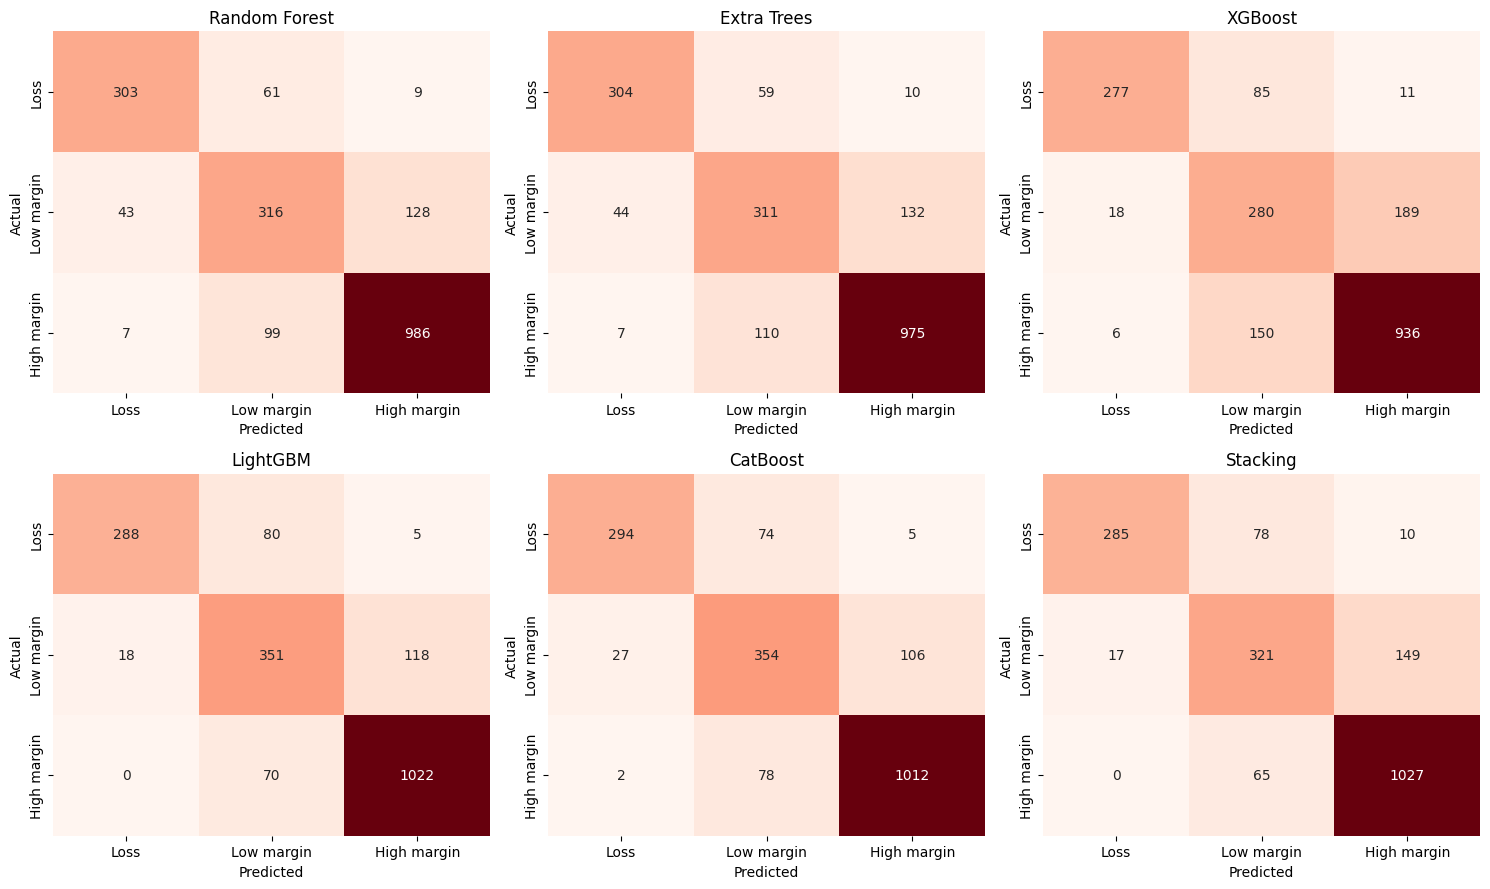

In [74]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (name, (pred, proba)) in zip(axes.ravel(), models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", cbar=False, ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()
